
--- Resultados da Simulação de Monte Carlo ---
Média de passos até absorção: 3.3321
Probabilidade de morrer na posição 0 vindo da posição 1: 0.6679
Probabilidade de morrer na posição 3 vindo da posição 1: 0.3321
Probabilidade de morrer na posição 0 vindo da posição 2: 0.3343
Probabilidade de morrer na posição 3 vindo da posição 2: 0.6657
Probabilidade de absorção exatamente no terceiro passo da posição 1: 0.1462

--- Resultados Teóricos ---
Média de passos até absorção: 3.3333
Probabilidade de morrer na posição 0 vindo da posição 1: 0.6667
Probabilidade de morrer na posição 3 vindo da posição 1: 0.3333
Probabilidade de morrer na posição 0 vindo da posição 2: 0.3333
Probabilidade de morrer na posição 3 vindo da posição 2: 0.6667
Probabilidade de absorção exatamente no terceiro passo da posição 1: 0.1470

--- Gráficos ---


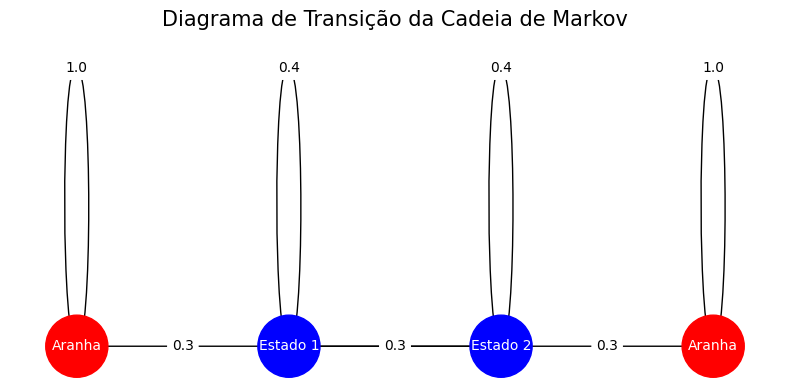

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

NN=300000 #Simulações de Monte Carlo
p_s=0.4 #probabilidade de permanecer no mesmo lugar
p_r=0.6 #probabilidade de movimento

# Inicializar contadores
P1_0 = 0
P1_1 = 0
P1_2 = 0
P2_1 = 0
P2_2 = 0
P2_3 = 0
passos_ate_morte = np.zeros(NN) # passos até a morte
D1_0 = 0 # Morte na posição 0 vindo da posição 1
D1_3 = 0 # Morte na posição 3 vindo da posição 1
D2_0 = 0 # Morte na posição 0 vindo da posição 2
D2_3 = 0 # Morte na posição 3 vindo da posição 2
contagem_inicio_pos1 = 0
passos_ate_morte_de_1 = []
morte_no_passo3_de_1 = 0

for i in range(NN):
    # Gerar posição inicial
    M_rt = 0 # Passos em tempo real
    P = 0 # Reiniciar posição
    D = -1 # Inicializar posição de morte para estado inválido

    s0 = np.random.uniform(0, 1)
    if s0 < 0.5:
        P = 1
        SP = 1
        contagem_inicio_pos1 += 1
    else:
        P = 2
        SP = 2

    while (P != 0 and P != 3):
        s1 = np.random.uniform(0, 1)
        M_rt += 1
        if P == 1:
            if s1 < p_s:
                P1_1 += 1
            else:
                s2 = np.random.uniform(0, 1)
                if s2 < 0.5:
                    P = P - 1
                    P1_0 += 1
                    D = 0 # Morte na posição 0
                else:
                    P = P + 1
                    P1_2 += 1
        elif P == 2:
            if s1 < p_s:
                P2_2 += 1
            else:
                s2 = np.random.uniform(0, 1)
                if s2 < 0.5:
                    P = P - 1
                    P2_1 += 1
                else:
                    P = P + 1
                    P2_3 += 1
                    D = 3 # Morte na posição 3

    passos_ate_morte[i] = M_rt

    # Rastrear absorções da posição 1
    if SP == 1:
        passos_ate_morte_de_1.append(M_rt)
        if M_rt == 3:
            morte_no_passo3_de_1 += 1

        if P == 0:  # Morreu na posição 0
            D1_0 += 1
        elif P == 3:  # Morreu na posição 3
            D1_3 += 1
    elif SP == 2:
        if P == 0:  # Morreu na posição 0
            D2_0 += 1
        elif P == 3:  # Morreu na posição 3
            D2_3 += 1

# Calcular probabilidades corretamente
media_passos = np.mean(passos_ate_morte) # Média de passos até absorção

# Probabilidade de morrer na posição 1 (dividir pelo número de testes começando na posição 1)
P_D_1_0 = D1_0 / contagem_inicio_pos1
P_D_1_3 = D1_3 / contagem_inicio_pos1

# Probabilidade de morrer na posição 2 (dividir pelo número de testes começando na posição 2)
P_D_2_0 = D2_0 / (NN - contagem_inicio_pos1)
P_D_2_3 = D2_3 / (NN - contagem_inicio_pos1)

# Probabilidade de absorção exatamente no terceiro passo da posição 1
P_D_3_de_1 = morte_no_passo3_de_1 / contagem_inicio_pos1

# Cálculos teóricos
MP = np.array([
    [1.0, 0.0, 0.0, 0.0],
    [0.3, 0.4, 0.3, 0.0],
    [0.0, 0.3, 0.4, 0.3],
    [0.0, 0.0, 0.0, 1.0]
])
Q = MP[1:3, 1:3]  # Submatriz para estados transientes
R = MP[1:3, [0,3]] # Submatriz para estados absorventes
I = np.eye(2)
N = np.linalg.inv(I - Q)  # Matriz fundamental
t = N.sum(axis=1)  # Tempo médio até absorção
t = (t[0]+t[1])/2
B = N @ R  # Probabilidades de absorção

# Calcular probabilidade de absorção exatamente em 3 passos (teórico)
P_3_passos = np.linalg.matrix_power(MP, 3)
# Para absorção exatamente no passo 3, precisamos de P^3 - P^2 para estados absorventes
P_2_passos = np.linalg.matrix_power(MP, 2)
prob_absorver_exatamente_3_passos = (P_3_passos[1, 0] - P_2_passos[1, 0]) + (P_3_passos[1, 3] - P_2_passos[1, 3])

# Imprimir resultados
print("\n--- Resultados da Simulação de Monte Carlo ---")
print(f"Média de passos até absorção: {media_passos:.4f}")
print(f"Probabilidade de morrer na posição 0 vindo da posição 1: {P_D_1_0:.4f}")
print(f"Probabilidade de morrer na posição 3 vindo da posição 1: {P_D_1_3:.4f}")
print(f"Probabilidade de morrer na posição 0 vindo da posição 2: {P_D_2_0:.4f}")
print(f"Probabilidade de morrer na posição 3 vindo da posição 2: {P_D_2_3:.4f}")
print(f"Probabilidade de absorção exatamente no terceiro passo da posição 1: {P_D_3_de_1:.4f}")

print("\n--- Resultados Teóricos ---")
print(f"Média de passos até absorção: {t:.4f}")
print(f"Probabilidade de morrer na posição 0 vindo da posição 1: {B[0,0]:.4f}")
print(f"Probabilidade de morrer na posição 3 vindo da posição 1: {B[0,1]:.4f}")
print(f"Probabilidade de morrer na posição 0 vindo da posição 2: {B[1,0]:.4f}")
print(f"Probabilidade de morrer na posição 3 vindo da posição 2: {B[1,1]:.4f}")
print(f"Probabilidade de absorção exatamente no terceiro passo da posição 1: {prob_absorver_exatamente_3_passos:.4f}")
print("\n--- Gráficos ---")

# Visualização da cadeia de Markov
G = nx.DiGraph()

# Adicionar nós
G.add_node(0, pos=(0, 0), color='red', label='Aranha')
G.add_node(1, pos=(1, 0), color='blue', label='Estado 1')
G.add_node(2, pos=(2, 0), color='blue', label='Estado 2')
G.add_node(3, pos=(3, 0), color='red', label='Aranha')

# Adicionar arestas com probabilidades
G.add_edge(1, 0, weight=0.3, label='0.3')
G.add_edge(1, 1, weight=0.4, label='0.4')
G.add_edge(1, 2, weight=0.3, label='0.3')
G.add_edge(2, 1, weight=0.3, label='0.3')
G.add_edge(2, 2, weight=0.4, label='0.4')
G.add_edge(2, 3, weight=0.3, label='0.3')
G.add_edge(0, 0, weight=1.0, label='1.0')
G.add_edge(3, 3, weight=1.0, label='1.0')

# Desenhar o grafo
plt.figure(figsize=(8, 4))
pos = nx.get_node_attributes(G, 'pos')
node_colors = [G.nodes[n]['color'] for n in G.nodes()]
labels = nx.get_node_attributes(G, 'label')

# Desenhar nós
nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=2000)
nx.draw_networkx_labels(G, pos, labels=labels, font_size=10, font_color='white')

# Desenhar arestas
edge_labels = {(u, v): d['label'] for u, v, d in G.edges(data=True)}
nx.draw_networkx_edges(G, pos, width=1.0, arrowstyle='->', arrowsize=15)
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=10)

# Adicionar título
plt.title('Diagrama de Transição da Cadeia de Markov', fontsize=15)
plt.axis('off')
plt.tight_layout()
plt.show()

